# Figure 4 — Melody motif perturbation analysis

This notebook reproduces panels **B / C / D / E** of Figure 4 directly from the exported CSV source files.

**Background.** To dissect how sequence-resolved perturbations influence DNA methylation across regulatory contexts, we performed a motif-centered allelic perturbation analysis with Melody. We curated **282 transcription factor motifs** and, for each motif, inserted a representative instance into genomic methylation blocks (≥ 4 CpG sites) drawn from the training set, scanning positions from 600 bp upstream of the block start to 600 bp downstream of its end. The motif effect at each position is defined as the difference between the predicted methylation of the motif-inserted sequence and the original sequence. Melody-MT is used as the predictor.

**Panels and source CSVs**

| Panel | CSV | Content |
| --- | --- | --- |
| Figure 4B | `figure_4B.csv` | Strength vs. specificity for all 282 motifs |
| Figure 4C | `figure_4C.csv` | Motif effects aggregated by chromatin-state group |
| Figure 4D | `figure_4D.csv` | Positional effect profiles of representative motifs across 6 tissues |
| Figure 4E | `figure_4E.csv` | Motif × cell-type effect matrix used for the clustermap |

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_DIR = next((os.path.join(r, 'Data', 'Figure4') for r in (os.getcwd(), os.path.dirname(os.getcwd())) if os.path.isdir(os.path.join(r, 'Data', 'Figure4'))), './Data/Figure4')

# Figure 4B — Motif strength vs. tissue specificity

Scatterplot of all 282 transcription factor motifs in a two-dimensional summary space:

- **Strength** — maximal absolute motif effect along the positional curve (how strongly a motif perturbs methylation).
- **Specificity** — variance of motif effects across tissues (how cell-type-restricted the response is).

Motifs in the top-10 by strength are labelled in **red**, and motifs in the top-10 by specificity are labelled in **blue**. Motifs such as *HD/10* and *NR/1* score high on both axes, highlighting their potential roles as lineage-restricted regulators of methylation landscapes.

shape = (282, 3)
Top 10 Strong Motifs:
  SPI  strength=0.8728
  HD/10  strength=0.8696
  IRF/2  strength=0.8401
  REST/NRSF  strength=0.8124
  CTCF  strength=0.7723
  NR/1  strength=0.7352
  PRDM1  strength=0.6629
  FOX/6  strength=0.6569
  RFX/1  strength=0.5628
  ZNF146  strength=0.5601

Top 10 Specific Motifs:
  HD/10  specificity=0.2577
  NR/1  specificity=0.1800
  FOX/6  specificity=0.1644
  SPI  specificity=0.1463
  IRF/2  specificity=0.1394
  P53-like/1  specificity=0.1169
  EVI1/MECOM  specificity=0.0890
  REST/NRSF  specificity=0.0811
  CTCF  specificity=0.0803
  GRHL  specificity=0.0723


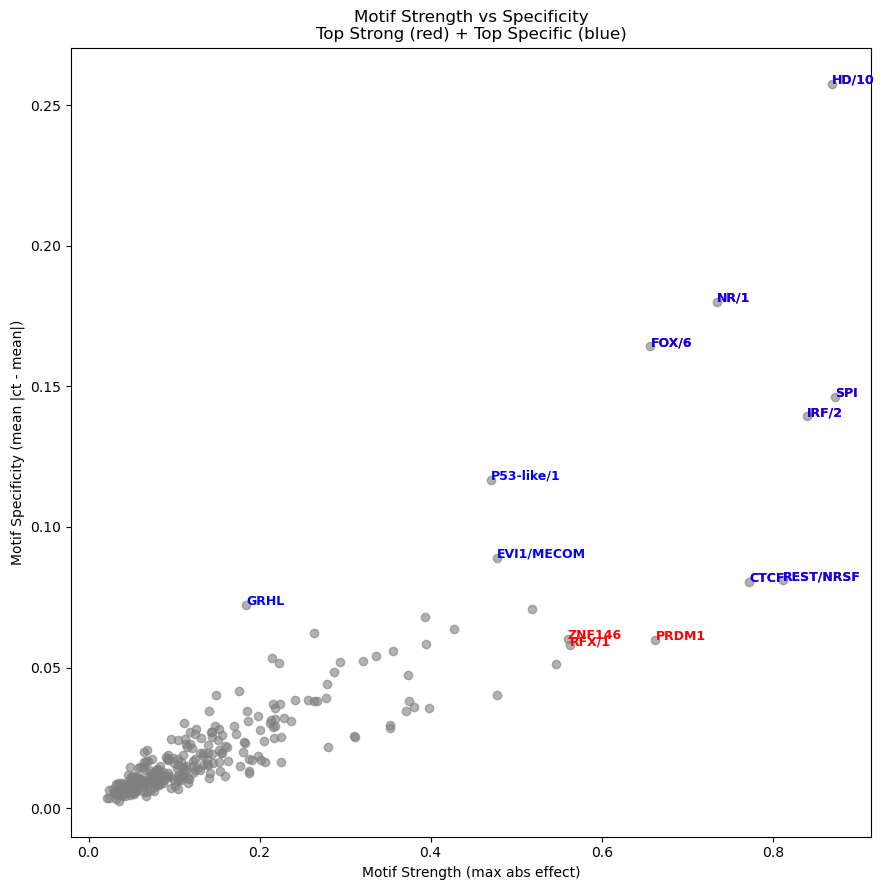

In [2]:
df_4B = pd.read_csv(os.path.join(CSV_DIR, 'figure_4B.csv'))
print('shape =', df_4B.shape)

motif_names = df_4B['motif'].to_numpy()
x_strength = df_4B['strength'].to_numpy()
y_specificity = df_4B['specificity'].to_numpy()

idx_strong = np.argsort(-x_strength)[:10]
idx_specific = np.argsort(-y_specificity)[:10]

print('Top 10 Strong Motifs:')
for i in idx_strong:
    print(f'  {motif_names[i]}  strength={x_strength[i]:.4f}')
print('\nTop 10 Specific Motifs:')
for i in idx_specific:
    print(f'  {motif_names[i]}  specificity={y_specificity[i]:.4f}')

plt.figure(figsize=(9, 9))
plt.scatter(x_strength, y_specificity, alpha=0.6, color='gray')
for i in idx_strong:
    plt.text(x_strength[i], y_specificity[i], motif_names[i],
             fontsize=9, color='red', weight='bold')
for i in idx_specific:
    plt.text(x_strength[i], y_specificity[i], motif_names[i],
             fontsize=9, color='blue', weight='bold')
plt.xlabel('Motif Strength (max abs effect)')
plt.ylabel('Motif Specificity (mean |ct - mean|)')
plt.title('Motif Strength vs Specificity\nTop Strong (red) + Top Specific (blue)')
plt.tight_layout()
plt.show()

# Figure 4C — Motif effect distribution across chromatin-state groups

Motif effects are aggregated into consolidated chromatin states (**Promoter, Enhancer, Transcribed, Repressed, Heterochromatin**) and contrasted pairwise. The violin/box plot shows the distribution, across all 282 motifs, of the *difference* in mean motif effect between the two states in each pair.

Promoter regions show the greatest magnitude of variation, while enhancers are less distinct than typically assumed. Repressed regions display unexpectedly strong and coherent effects that are markedly different from enhancers, suggesting fundamentally different regulatory mechanisms. Despite these differences, motif-driven methylation responses remain broadly stable across chromatin states, consistent with sequence-intrinsic biochemistry dominating over chromatin context.

shape = (282, 7) | groups = ['Promoter', 'Enhancer', 'Transcribed', 'Repressed', 'Heterochromatin', 'ZNF', 'Quiescent']


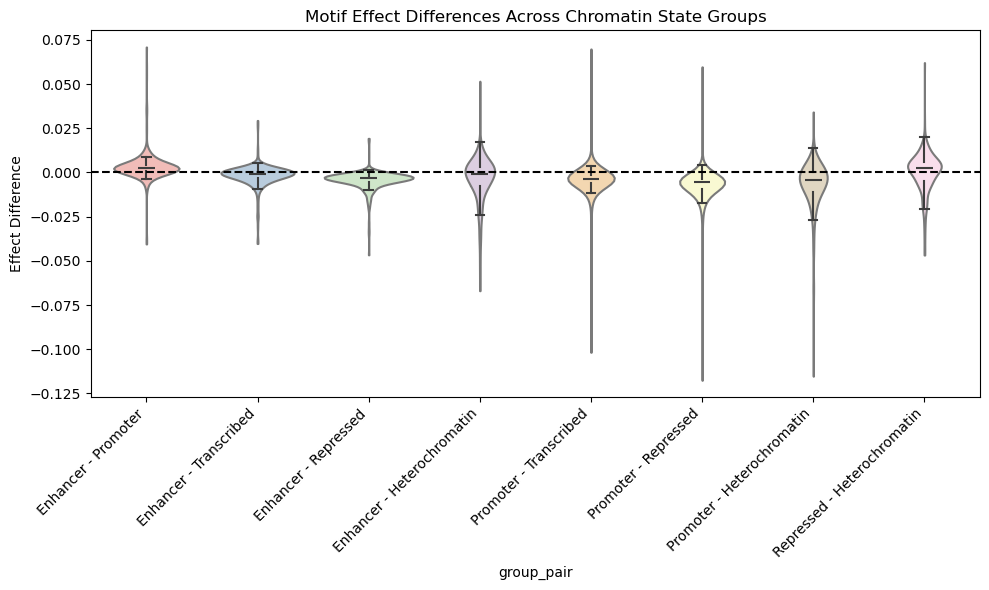

In [3]:
df_4C = pd.read_csv(os.path.join(CSV_DIR, 'figure_4C.csv'), index_col='motif')
print('shape =', df_4C.shape, '| groups =', list(df_4C.columns))

group_pairs = [
    ('Enhancer', 'Promoter'),
    ('Enhancer', 'Transcribed'),
    ('Enhancer', 'Repressed'),
    ('Enhancer', 'Heterochromatin'),
    ('Promoter', 'Transcribed'),
    ('Promoter', 'Repressed'),
    ('Promoter', 'Heterochromatin'),
    ('Repressed', 'Heterochromatin'),
]

records = []
for g1, g2 in group_pairs:
    diff = df_4C[g1] - df_4C[g2]
    for motif, value in diff.items():
        records.append({
            'motif': motif,
            'group_pair': f'{g1} - {g2}',
            'difference': value,
        })
df_diff = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_diff,
    x='group_pair', y='difference',
    cut=0, inner=None, palette='Pastel1',
)
sns.boxplot(
    data=df_diff,
    x='group_pair', y='difference',
    width=0.15, showcaps=True,
    boxprops={'facecolor': 'white'},
    showfliers=False,
)
plt.axhline(0, linestyle='--', color='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Effect Difference')
plt.title('Motif Effect Differences Across Chromatin State Groups')
plt.tight_layout()
plt.show()

# Figure 4D — Positional effect profiles for representative motifs

Per-position motif effect curves for eight representative motifs (`RFX/2`, `IRF/2`, `SPI`, `CTCF`, `REST/NRSF`, `YY1`, `ZNF85`, `HD/10`) across six tissues drawn from the 39-tissue panel: *Heart-Cardiomyocyte, Liver-Hepatocytes, Kidney-Tubular, Blood-T, Blood-Monocytes, Pancreas-Beta*.

- *ZNF85* produces a positive local methylation shift, while *HD/10*, *SPI*, *IRF/2*, and *CTCF* produce negative shifts.
- Tissue-specific differences are apparent: *HD/10* shows stronger effects in liver and pancreas, whereas *SPI* and *IRF/2* peak in blood-derived cell types.
- *CTCF* exhibits a characteristic non-smooth, oscillatory pattern reminiscent of nucleosome phasing, with a pronounced local loss of methylation proximal to the motif — consistent with CTCF acting as a methylation-sensitive insulator that protects CpGs from DNMT activity and promotes demethylation via TET recruitment.

shape = (1920, 8) | columns = ['motif', 'position', 'Heart-Cardiomyocyte', 'Liver-Hepatocytes', 'Kidney-Tubular', 'Blood-T', 'Blood-Monocytes', 'Pancreas-Beta']
motifs = ['RFX/2', 'IRF/2', 'SPI', 'CTCF', 'REST/NRSF', 'YY1', 'ZNF85', 'HD/10']
cell types = ['Heart-Cardiomyocyte', 'Liver-Hepatocytes', 'Kidney-Tubular', 'Blood-T', 'Blood-Monocytes', 'Pancreas-Beta']


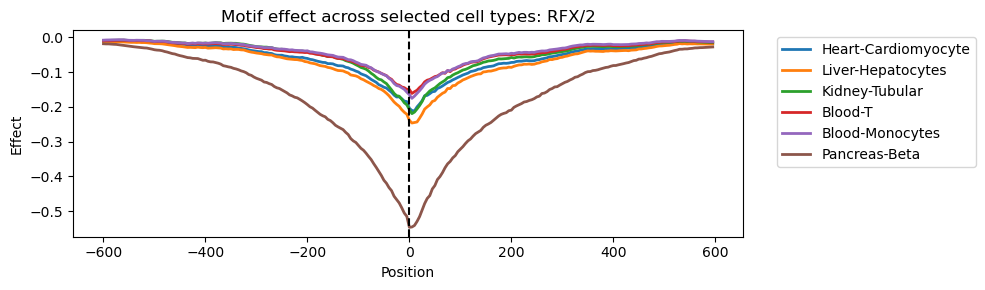

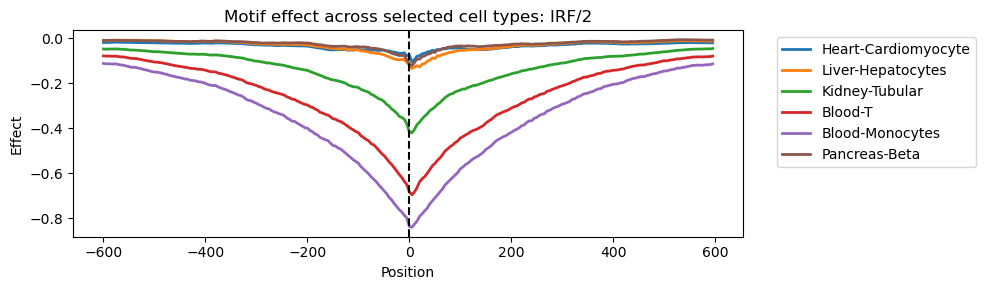

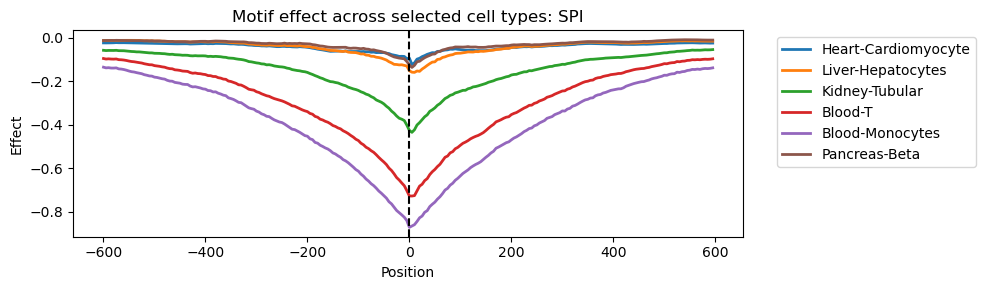

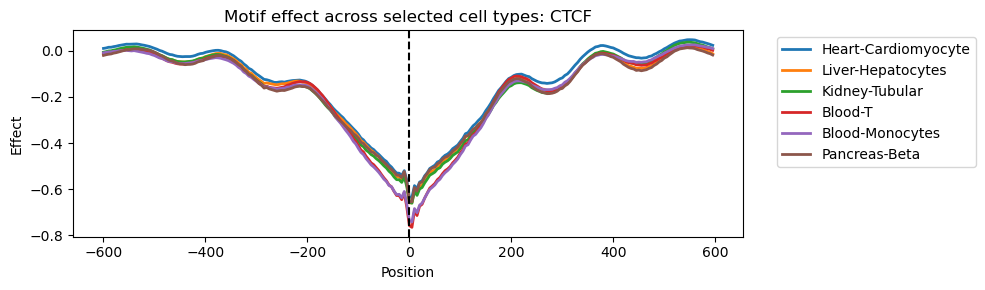

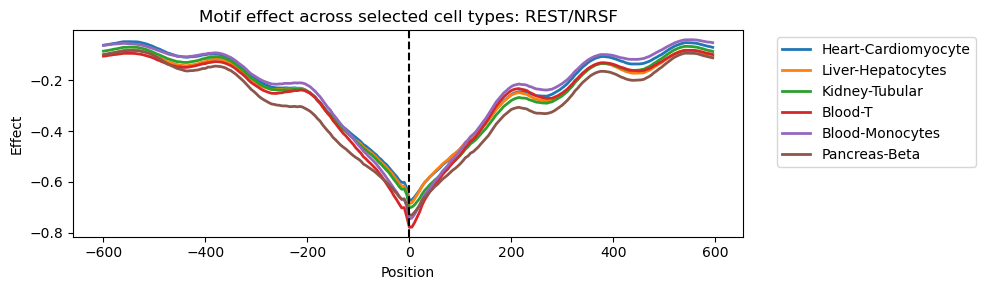

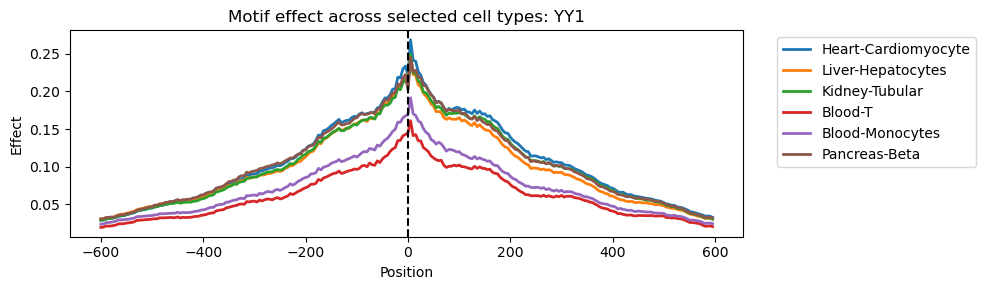

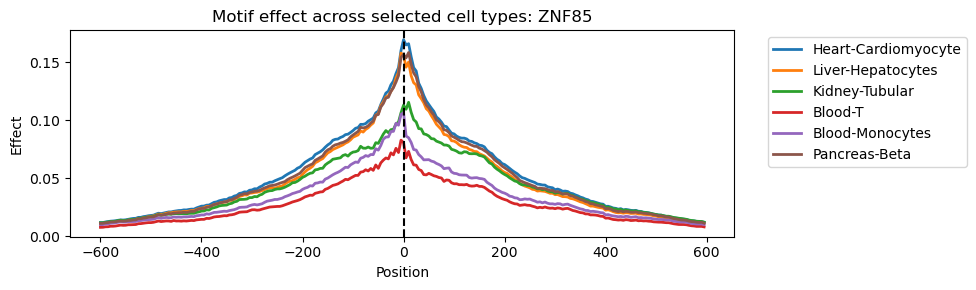

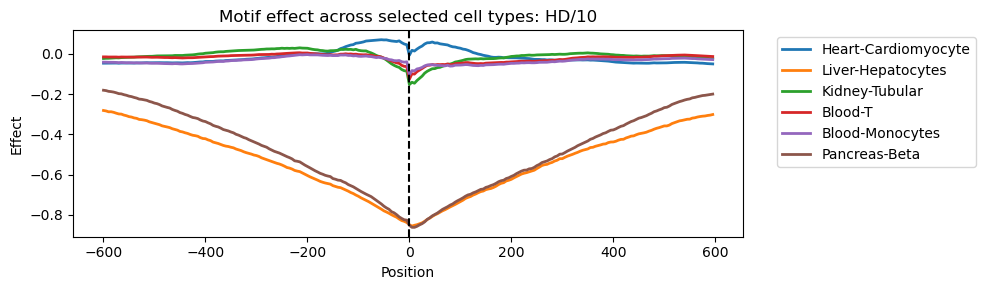

In [4]:
df_4D = pd.read_csv(os.path.join(CSV_DIR, 'figure_4D.csv'))
print('shape =', df_4D.shape, '| columns =', list(df_4D.columns))

motif_order = list(dict.fromkeys(df_4D['motif'].tolist()))
celltype_cols = [c for c in df_4D.columns if c not in ('motif', 'position')]
print('motifs =', motif_order)
print('cell types =', celltype_cols)

palette = sns.color_palette('tab10', len(celltype_cols))
ct_colors = {ct: palette[i] for i, ct in enumerate(celltype_cols)}


def plot_motif(motif_name, df=df_4D):
    sub = df[df['motif'] == motif_name].sort_values('position')
    plt.figure(figsize=(10, 3))
    for ct in celltype_cols:
        plt.plot(sub['position'], sub[ct], label=ct, color=ct_colors[ct], linewidth=2)
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f'Motif effect across selected cell types: {motif_name}')
    plt.xlabel('Position')
    plt.ylabel('Effect')
    plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


for name in motif_order:
    plot_motif(name)

# Figure 4E — Motif × tissue heatmap

Heatmap of methylation effects across motifs and tissues. To keep the figure readable, motifs are first ranked by `max |effect|` and the **top-100 motifs** are retained; rows and columns are then hierarchically clustered (correlation distance, average linkage) and the colour scale is symmetrically clipped at the 99.5% quantile.

Cross-tissue perturbation modules emerge clearly: global architectural regulators such as *CTCF* and *REST* form broad, pan-tissue clusters, whereas blood-derived cell types cluster strongly together, dominated by hematopoietic lineage factors *SPI* and *IRF/2*. These patterns recapitulate known transcriptional hierarchies and demonstrate that Melody captures both global and lineage-specific regulators of DNA methylation.

shape = (39, 282) (cell_types × motifs)
top-k shape: (100, 39)


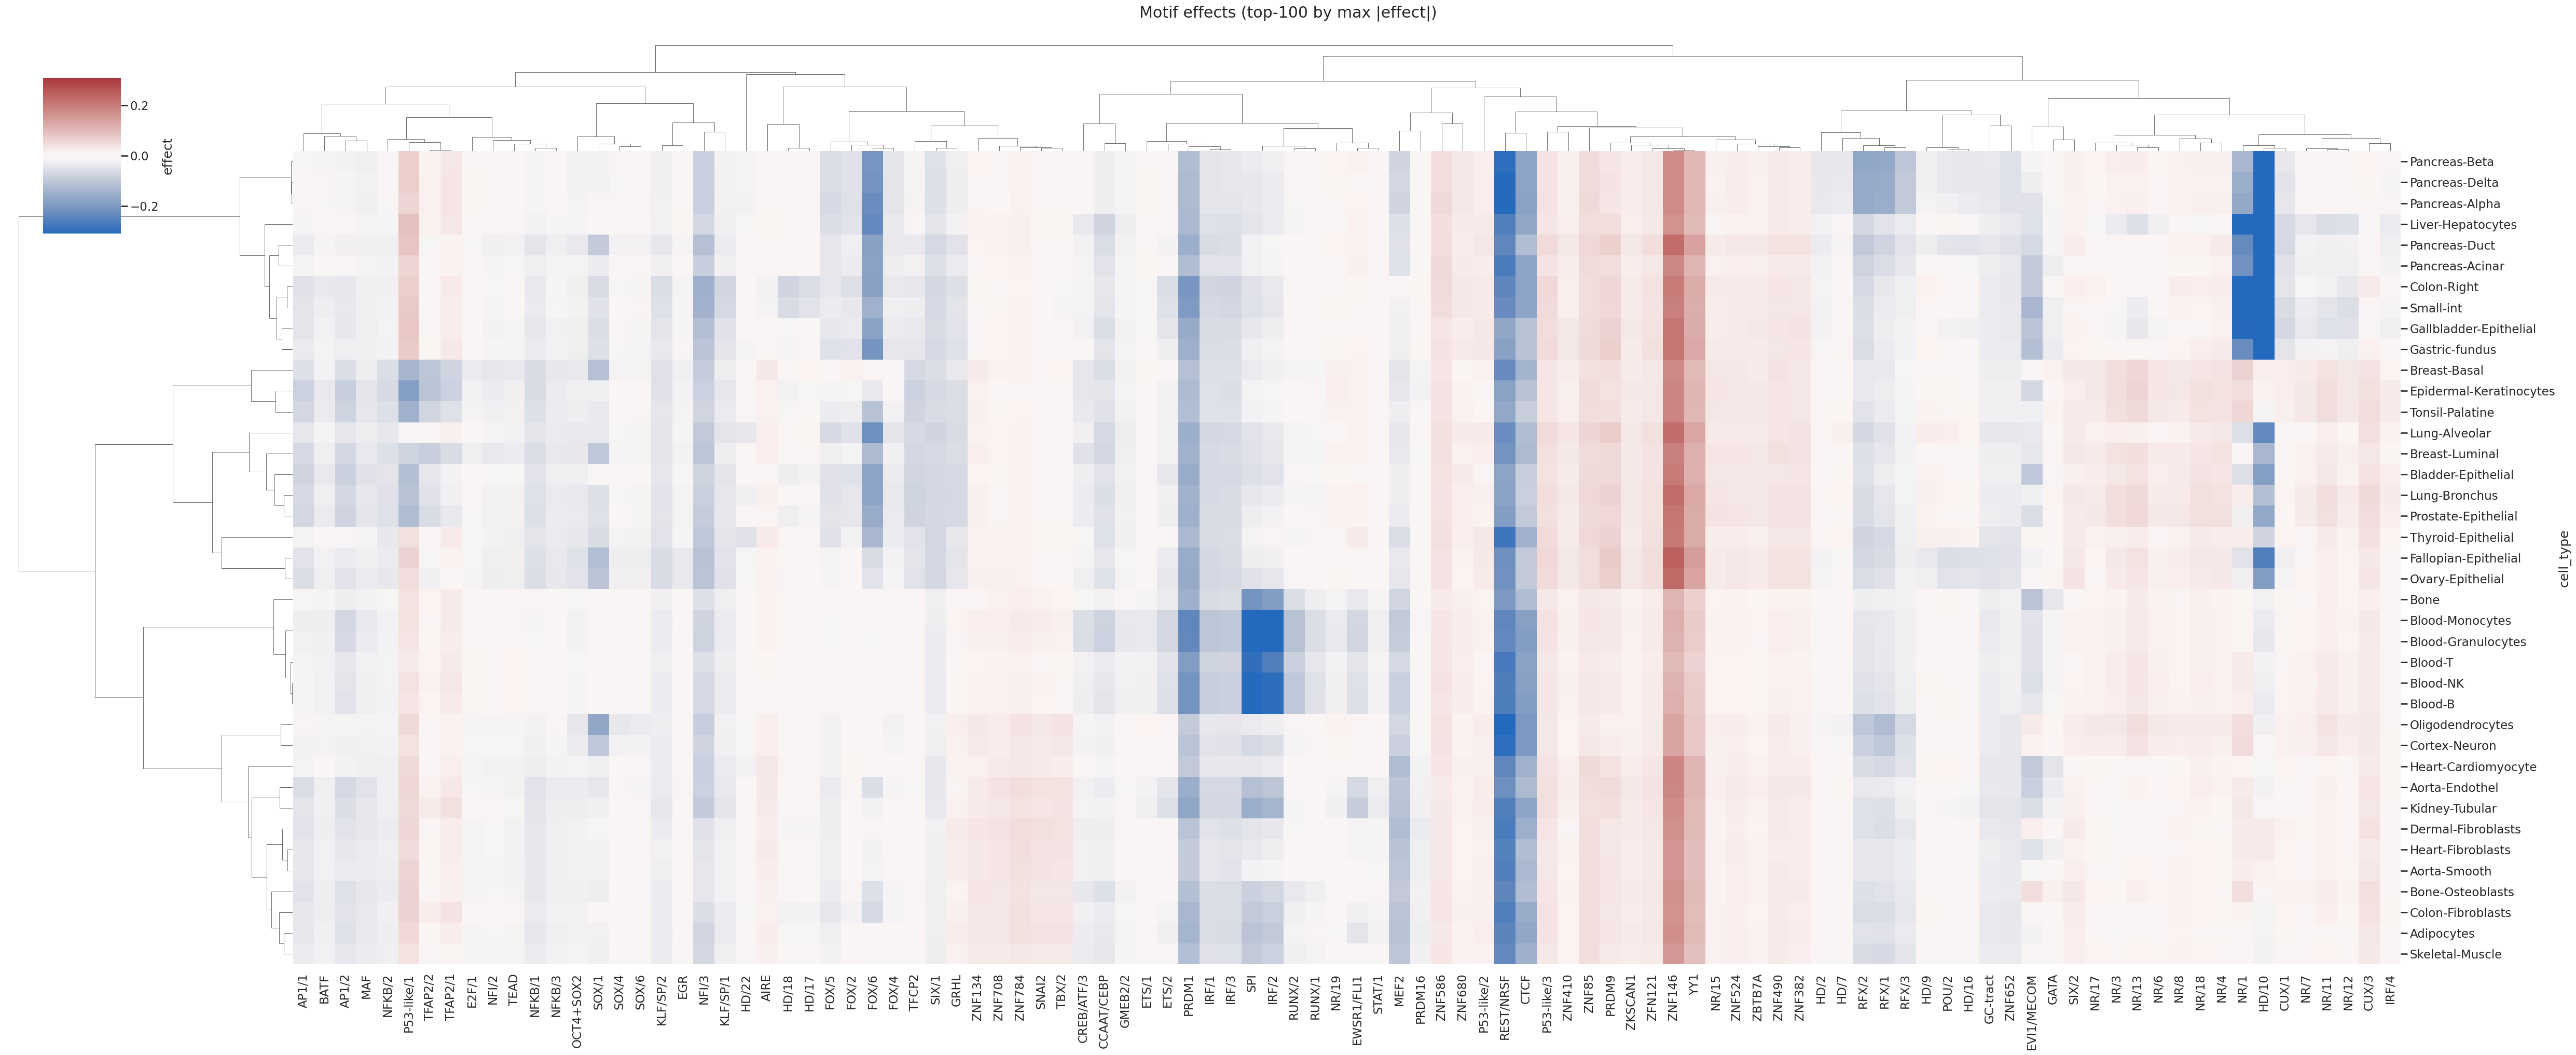

In [5]:
data_mean_df = pd.read_csv(os.path.join(CSV_DIR, 'figure_4E.csv'), index_col='cell_type')
print('shape =', data_mean_df.shape, '(cell_types × motifs)')


def keep_topk_motifs(df, k=200, metric='max_abs'):
    """Keep the top-k motifs ranked by overall effect magnitude.

    Parameters
    ----------
    df : pandas.DataFrame
        Rows are motifs and columns are cell types.
    k : int
        Number of motifs to keep.
    metric : {'max_abs', 'l2', 'abs_mean'}
        Ranking statistic computed per motif (per row).
    """
    if metric == 'max_abs':
        score = df.abs().max(axis=1)
    elif metric == 'l2':
        score = pd.Series(np.sqrt((df.values ** 2).sum(axis=1)), index=df.index)
    elif metric == 'abs_mean':
        score = df.abs().mean(axis=1)
    else:
        raise ValueError('metric must be one of: max_abs | l2 | abs_mean')
    top = score.sort_values(ascending=False).head(k).index
    return df.loc[top]


def prettier_clustermap(
    df,
    transpose=True,
    zscore=None,
    cmap='vlag',
    quantile=0.995,
    metric='correlation',
    method='average',
    figsize=None,
    title=None,
):
    X = df.T if transpose else df

    if zscore == 'row':
        mu = np.nanmean(X.values, axis=1, keepdims=True)
        sd = np.nanstd(X.values, axis=1, keepdims=True)
        Xz = (X.values - mu) / np.where(sd == 0, np.nan, sd)
        Xp = pd.DataFrame(Xz, index=X.index, columns=X.columns)
    elif zscore == 'col':
        mu = np.nanmean(X.values, axis=0, keepdims=True)
        sd = np.nanstd(X.values, axis=0, keepdims=True)
        Xz = (X.values - mu) / np.where(sd == 0, np.nan, sd)
        Xp = pd.DataFrame(Xz, index=X.index, columns=X.columns)
    else:
        Xp = X

    a = float(np.nanquantile(np.abs(Xp.values), quantile))
    vmin, vmax = -a, a

    if figsize is None:
        w = min(24, 0.25 * Xp.shape[1] + 6)
        h = min(20, 0.25 * Xp.shape[0] + 4)
        figsize = (w, h)

    sns.set_context('talk')
    sns.set_style('white')

    g = sns.clustermap(
        Xp,
        cmap=cmap, center=0.0, vmin=vmin, vmax=vmax,
        metric=metric, method=method,
        figsize=figsize, dendrogram_ratio=(0.12, 0.12),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
        cbar_kws={'label': 'effect', 'shrink': 0.8},
    )
    if title:
        g.fig.suptitle(title, y=1.02)
    return g


# `data_mean_df` is stored as cell_type x motif; transpose so that rows are motifs,
# then keep only the top-100 motifs by max |effect|.
data_mean_df_sorted = keep_topk_motifs(data_mean_df.T, k=100, metric='max_abs')
print('top-k shape:', data_mean_df_sorted.shape)

prettier_clustermap(
    data_mean_df_sorted,
    transpose=True,
    zscore=None,
    cmap='vlag',
    title='Motif effects (top-100 by max |effect|)',
    figsize=(50, 20),
)
plt.show()